In [1]:
import pandas as pd
import numpy as np

archivos = [f'datos-fallecidos-en-siniestros-de-trnsito-{a}.csv' for a in range(2013, 2019)]
df = pd.concat([pd.read_csv(f, encoding='latin1') for f in archivos], ignore_index=True)

df.columns = df.columns.str.strip()  # "Jurisdiccion " tiene un espacio de mas
df['Fecha y hora'] = pd.to_datetime(df['Fecha y hora'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df['anio'] = df['Fecha y hora'].dt.year
df['mes'] = df['Fecha y hora'].dt.month
df['hora'] = df['Fecha y hora'].dt.hour
df['dia_semana'] = df['Fecha y hora'].dt.dayofweek  # 0=lunes

df['muerte_demorada'] = (df['Fallecido a los Dias'] > 0).astype(int)

print("Filas:", len(df))
print(df['muerte_demorada'].value_counts(normalize=True).round(3))
print()
print(df[['Departamento','Vehiculo','Rol','Sexo','Tipo de Siniestro']].nunique())

Filas: 3055
muerte_demorada
0    0.592
1    0.408
Name: proportion, dtype: float64

Departamento         19
Vehiculo             14
Rol                   3
Sexo                  2
Tipo de Siniestro     6
dtype: int64


In [2]:
df['edad_num'] = pd.to_numeric(df['Edad'], errors='coerce')
df['con_otro_vehiculo'] = df['Otro vehiculo'].notna().astype(int)  # siniestro con 1 vs 2+ vehiculos

features_cat = ['Departamento', 'Vehiculo', 'Rol', 'Sexo', 'Tipo de Siniestro', 'dia_semana']
features_num = ['edad_num', 'hora', 'con_otro_vehiculo']

base = df.dropna(subset=features_cat + features_num + ['muerte_demorada']).copy()
print(f"Filas para el modelo: {len(base)} (de {len(df)})")

# Categorias con muy pocos casos generan ruido; agrupamos las de Vehiculo con <30 casos como "OTRO"
conteo_vehiculo = base['Vehiculo'].value_counts()
categorias_chicas = conteo_vehiculo[conteo_vehiculo < 30].index
base['Vehiculo'] = base['Vehiculo'].replace(dict.fromkeys(categorias_chicas, 'OTRO'))

base['Vehiculo'].value_counts()

Filas para el modelo: 3011 (de 3055)


Vehiculo
MOTO         1475
AUTO          594
PEATÓN        485
CAMIONETA     234
BICICLETA     152
CAMION         37
OTRO           34
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = base[features_cat + features_num]
y = base['muerte_demorada']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

preprocesador = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
    ('num', StandardScaler(), features_num),
])

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(y_train.value_counts(normalize=True).round(3))

Train: 2258 | Test: 753
muerte_demorada
0    0.592
1    0.408
Name: proportion, dtype: float64


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

resultados = []

def evaluar(nombre, pipeline, X_test, y_test, denso=False):
    Xt = X_test
    y_pred = pipeline.predict(Xt)
    y_proba = pipeline.predict_proba(Xt)[:, 1]
    m = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
    }
    resultados.append(m)
    print(f"--- {nombre} ---")
    for k, v in m.items():
        if k != 'modelo':
            print(f"{k}: {v:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print()
    return y_proba

pipe_logit = Pipeline([('prep', preprocesador), ('clf', LogisticRegression(max_iter=1000))])
pipe_logit.fit(X_train, y_train)
proba_logit = evaluar('Regresion logistica', pipe_logit, X_test, y_test)

pipe_rf = Pipeline([('prep', preprocesador), ('clf', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42))])
pipe_rf.fit(X_train, y_train)
proba_rf = evaluar('Random Forest', pipe_rf, X_test, y_test)

pipe_nb = Pipeline([('prep', preprocesador), ('clf', GaussianNB())])
X_train_dense = preprocesador.fit_transform(X_train).toarray()
X_test_dense = preprocesador.transform(X_test).toarray()
nb = GaussianNB().fit(X_train_dense, y_train)
y_pred_nb = nb.predict(X_test_dense)
y_proba_nb = nb.predict_proba(X_test_dense)[:, 1]
resultados.append({
    'modelo': 'Naive Bayes',
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb),
    'recall': recall_score(y_test, y_pred_nb),
    'f1': f1_score(y_test, y_pred_nb),
    'auc': roc_auc_score(y_test, y_proba_nb),
})
print(confusion_matrix(y_test, y_pred_nb))

tabla = pd.DataFrame(resultados).set_index('modelo').sort_values('auc', ascending=False)
tabla

--- Regresion logistica ---
accuracy: 0.611
precision: 0.544
recall: 0.283
f1: 0.373
auc: 0.621
[[373  73]
 [220  87]]

--- Random Forest ---
accuracy: 0.629
precision: 0.625
recall: 0.228
f1: 0.334
auc: 0.646
[[404  42]
 [237  70]]

[[161 285]
 [ 90 217]]


,accuracy,precision,recall,f1,auc
modelo,,,,,
Random Forest,0.629482,0.625000,0.228013,0.334129,0.645977
Regresion logistica,0.610890,0.543750,0.283388,0.372591,0.620675
Naive Bayes,0.501992,0.432271,0.706840,0.536465,0.559852


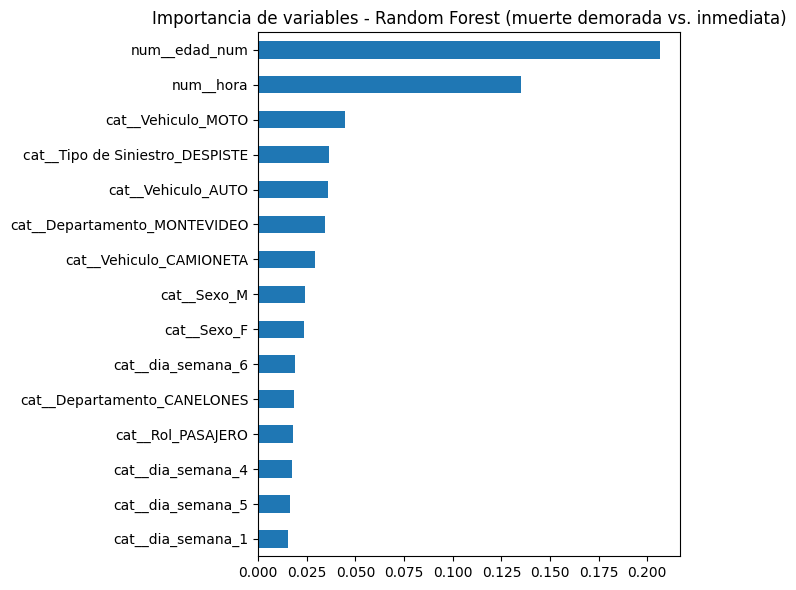

Top OR (mayor prob. de muerte demorada):
cat__Vehiculo_BICICLETA                            2.228979
cat__Vehiculo_MOTO                                 2.174887
cat__Tipo de Siniestro_ATROPELLO DE PEATÓN         2.120223
cat__Departamento_DURAZNO                          1.549705
cat__Departamento_CERRO LARGO                      1.533072
cat__Departamento_LAVALLEJA                        1.334603
cat__Departamento_ARTIGAS                          1.299269
cat__Tipo de Siniestro_COLISIÓN ENTRE VEHÍCULOS    1.232301
dtype: float64

Top OR inverso (mayor prob. de muerte inmediata):
cat__Departamento_ROCHA                         0.734319
cat__Departamento_CANELONES                     0.731552
cat__Tipo de Siniestro_DESPISTE                 0.714585
cat__Vehiculo_CAMIONETA                         0.690345
cat__Departamento_RIVERA                        0.685902
cat__Vehiculo_OTRO                              0.639581
cat__Tipo de Siniestro_ATROPELLO DE ANIMALES    0.495917
cat__Vehiculo_

In [7]:
import matplotlib.pyplot as plt

nombres_cols = pipe_rf.named_steps['prep'].get_feature_names_out()
importancias = pd.Series(pipe_rf.named_steps['clf'].feature_importances_, index=nombres_cols)
importancias.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(7,6))
plt.gca().invert_yaxis()
plt.title('Importancia de variables - Random Forest (muerte demorada vs. inmediata)')
plt.tight_layout()
plt.show()

coefs = pd.Series(pipe_logit.named_steps['clf'].coef_[0], index=nombres_cols)
odds = np.exp(coefs).sort_values(ascending=False)
print("Top OR (mayor prob. de muerte demorada):")
print(odds.head(8))
print("\nTop OR inverso (mayor prob. de muerte inmediata):")
print(odds.tail(8))